In [ ]:
# Necessary Dependencies
import numpy as np
import pandas as pd
# !pip install utils - Removed for local execution
try:
    from utils import *
except ImportError:
    pass # In case utils is not available locally
from glob import glob
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from itertools import chain
from datetime import datetime
import statistics
from tqdm import tqdm
import tensorflow as tf

# Configure GPU memory growth for local execution
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Configured {len(gpus)} GPU(s) for memory growth.")
    except RuntimeError as e:
        print(e)

# DenseNet Dependencies
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.activations import sigmoid
from tensorflow.keras.layers import Dense,Conv2D, Flatten, Dropout, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.metrics import Accuracy, Precision, Recall, AUC, BinaryAccuracy, FalsePositives, FalseNegatives, TruePositives, TrueNegatives
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.applications import DenseNet121, DenseNet169, DenseNet201, VGG16, ResNet50
from keras import backend as K
from tensorflow.keras import Sequential
import keras
import matplotlib
from sklearn.metrics import roc_curve, auc, roc_auc_score
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler
from sklearn.metrics import roc_curve, auc
print('Started')

In [2]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
"./dataset-kaggle/train",
seed=123,
image_size=(128, 128),
batch_size=64
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
"./dataset-kaggle/test",
seed=123,
image_size=(128, 128),
batch_size=64,
    shuffle=False
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
"./dataset-kaggle/val",
seed=123,
image_size=(128, 128),
batch_size=64
)

Found 5778 files belonging to 5 classes.
Found 1656 files belonging to 5 classes.
Found 826 files belonging to 5 classes.


In [3]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true

array([0, 0, 0, ..., 4, 4, 4], dtype=int32)

In [4]:
def get_callbacks(model_name):
    callbacks =[]

    # Change the file extension to '.keras'
    checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath=f'model.{model_name}.keras',
                                                    verbose=1,
                                                    monitor='val_loss',
                                                    mode='min',
                                                    save_best_only=True)
    callbacks.append(checkpoint)
    #--------------------------------------------------------
    anne = ReduceLROnPlateau(monitor='val_loss',
                             factor=0.5,
                             patience=5,
                             verbose=2,
                             min_lr=0.0000001,
                             min_delta=0.00001,
                             mode='auto')
    callbacks.append(anne)
    #--------------------------------------------------------
    earlystop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                 patience=10)
    callbacks.append(earlystop)

    return callbacks

In [6]:
# Xception Model

# 1. Initialize the model WITHOUT downloading weights
base_model = tf.keras.applications.Xception(
    weights=None, # Changed from 'imagenet' to None
    input_shape=(128, 128, 3),
    include_top=False
)

# 2. Load the downloaded weights manually
# (Update the path depending on where you saved the .h5 file)
base_model.load_weights('xception_weights_tf_dim_ordering_tf_kernels_notop.h5')

base_model.trainable = True

# Add classification head
model = tf.keras.Sequential([
  base_model,
  tf.keras.layers.GlobalAveragePooling2D(),        # Flatten
  tf.keras.layers.Dense(5, activation='softmax')   # Last layer
])

#----------------------------------------------------
# Model Complie
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#----------------------------------------------------
epochs = 15
callbacks = get_callbacks('Xception')
history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=epochs,
                callbacks=callbacks
                )


Epoch 1/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4472 - loss: 1.2942
Epoch 1: val_loss improved from inf to 2.12684, saving model to model.Xception.keras
91/91 ━━━━━━━━━━━━━━━━━━━━ 245s 3s/step - accuracy: 0.4481 - loss: 1.2924 - val_accuracy: 0.4879 - val_loss: 2.1268 - learning_rate: 0.0010
Epoch 2/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6228 - loss: 0.9279
Epoch 2: val_loss improved from 2.12684 to 1.59603, saving model to model.Xception.keras
91/91 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step - accuracy: 0.6229 - loss: 0.9274 - val_accuracy: 0.5424 - val_loss: 1.5960 - learning_rate: 0.0010
Epoch 3/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6740 - loss: 0.7816
Epoch 3: val_loss improved from 1.59603 to 1.47665, saving model to model.Xception.keras
91/91 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.6742 - loss: 0.7811 - val_accuracy: 0.4588 - val_loss: 1.4766 - learning_rate: 0.0010
Epoch 4/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7377 

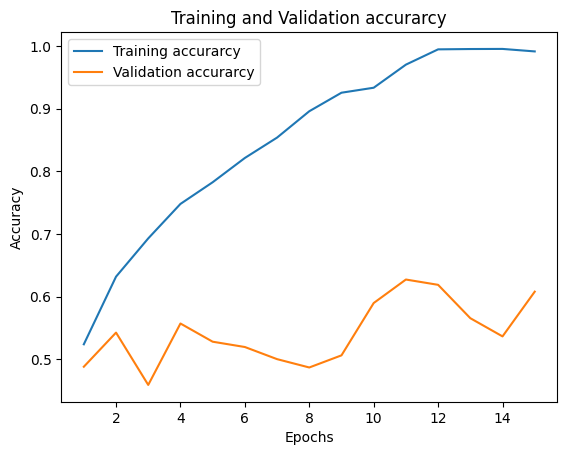

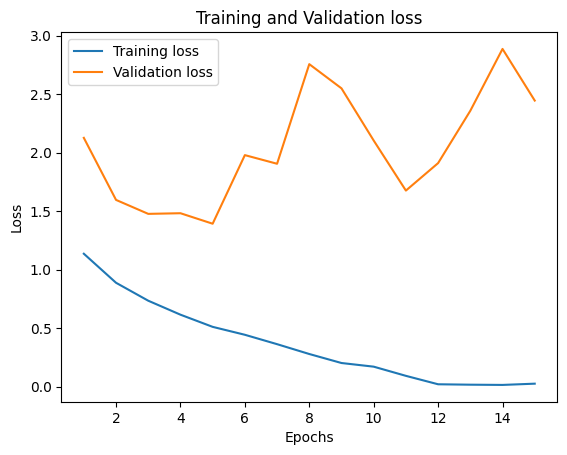

In [8]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

#Train and validation accuracy
plt.plot(epochs, acc, label='Training accurarcy')
plt.plot(epochs, val_acc, label='Validation accurarcy')
plt.title('Training and Validation accurarcy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.figure()
#Train and validation loss
plt.plot(epochs, loss,  label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [9]:
# load the DenseNet121 model

model = tf.keras.models.load_model('model.Xception.keras')

In [10]:
# Print the classiifcation report

from sklearn.metrics import classification_report
y_pred = model.predict(test_ds)
predicted_categories = np.argmax(y_pred, axis=1)
true_categories = y_true
print(classification_report(true_categories, predicted_categories, digits=4))


26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 504ms/step
              precision    recall  f1-score   support

           0     0.7140    0.6761    0.6945       639
           1     0.2570    0.5608    0.3524       296
           2     0.7500    0.1879    0.3005       447
           3     0.7097    0.7892    0.7473       223
           4     0.8000    0.7059    0.7500        51

    accuracy                         0.5399      1656
   macro avg     0.6461    0.5840    0.5690      1656
weighted avg     0.6441    0.5399    0.5359      1656



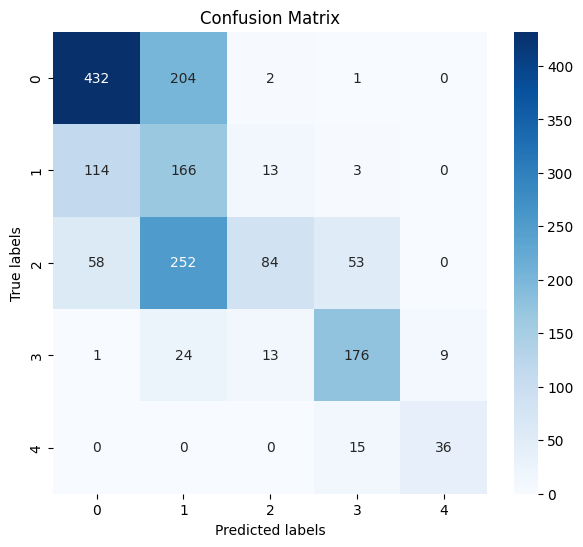

In [11]:
#  draw the confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get the confusion matrix
cm = confusion_matrix(true_categories, predicted_categories)

# Plot the confusion matrix
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues') #xticklabels=target_names, yticklabels=target_names
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()


In [18]:
# Xception Model

base_model = tf.keras.applications.DenseNet121(
    weights='imagenet',
    input_shape= (128,128,3),
    include_top=False
)

base_model.trainable = True

# Add classification head
model = tf.keras.Sequential([
  base_model,
  tf.keras.layers.GlobalAveragePooling2D(),        # Flatten
  tf.keras.layers.Dense(5, activation='softmax')   # Last layer
])

#----------------------------------------------------
# Model Complie
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#----------------------------------------------------
epochs = 50
callbacks = get_callbacks('DenseNet121')
history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=epochs,
                callbacks=callbacks
                )


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50


I0000 00:00:1731081798.724289     117 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_slice_fusion_1', 16 bytes spill stores, 16 bytes spill loads



90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.4236 - loss: 1.4535

I0000 00:00:1731081877.818606     116 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_slice_fusion_1', 16 bytes spill stores, 16 bytes spill loads



91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 877ms/step - accuracy: 0.4245 - loss: 1.4509
Epoch 1: val_loss improved from inf to 1.87932, saving model to model.DenseNet121.keras
91/91 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.4253 - loss: 1.4483 - val_accuracy: 0.4564 - val_loss: 1.8793 - learning_rate: 0.0010
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.5852 - loss: 0.9742
Epoch 2: val_loss did not improve from 1.87932
91/91 ━━━━━━━━━━━━━━━━━━━━ 18s 199ms/step - accuracy: 0.5854 - loss: 0.9737 - val_accuracy: 0.4540 - val_loss: 2.0165 - learning_rate: 0.0010
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.6492 - loss: 0.8460
Epoch 3: val_loss improved from 1.87932 to 1.27237, saving model to model.DenseNet121.keras
91/91 ━━━━━━━━━━━━━━━━━━━━ 20s 218ms/step - accuracy: 0.6492 - loss: 0.8458 - val_accuracy: 0.4576 - val_loss: 1.2724 - learning_rate: 0.0010
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.6618 - loss: 0.7924
Epoch 4: val_los

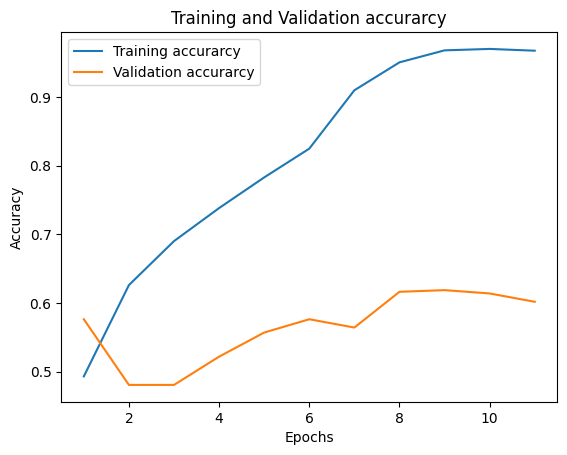

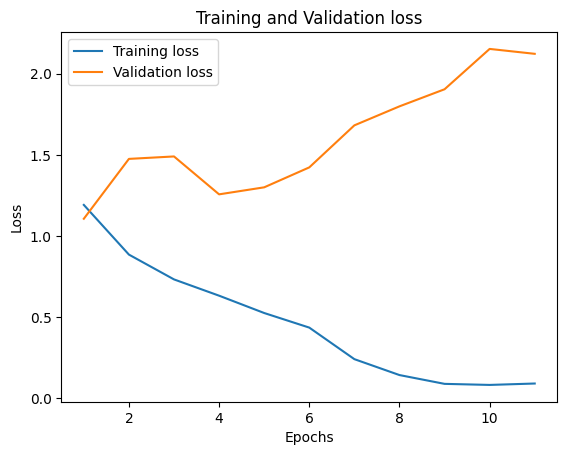

In [22]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

#Train and validation accuracy
plt.plot(epochs, acc, label='Training accurarcy')
plt.plot(epochs, val_acc, label='Validation accurarcy')
plt.title('Training and Validation accurarcy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.figure()
#Train and validation loss
plt.plot(epochs, loss,  label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [21]:
# model_3
# EfficientNetB2
# Xception Model

base_model = tf.keras.applications.EfficientNetB2(
    weights='imagenet',
    input_shape= (128,128,3),
    include_top=False
)

base_model.trainable = True

# Add classification head
model = tf.keras.Sequential([
  base_model,
  tf.keras.layers.GlobalAveragePooling2D(),        # Flatten
  tf.keras.layers.Dense(5, activation='softmax')   # Last layer
])

#----------------------------------------------------
# Model Complie
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#----------------------------------------------------
epochs = 50
callbacks = get_callbacks('EfficientNetB2')
history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=epochs,
                callbacks=callbacks
                )


31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 969ms/step - accuracy: 0.4167 - loss: 1.3462
Epoch 1: val_loss improved from inf to 1.10651, saving model to model.EfficientNetB2.keras
91/91 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.4176 - loss: 1.3445 - val_accuracy: 0.5763 - val_loss: 1.1065 - learning_rate: 0.0010
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.6023 - loss: 0.9339
Epoch 2: val_loss did not improve from 1.10651
91/91 ━━━━━━━━━━━━━━━━━━━━ 13s 141ms/step - accuracy: 0.6026 - loss: 0.9334 - val_accuracy: 0.4806 - val_loss: 1.4751 - learning_rate: 0.0010
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.6718 - loss: 0.7715
Epoch 3: val_loss did not improve from 1.10651
91/91 ━━━━━━━━━━━━━━━━━━━━ 13s 141ms/step - accuracy: 0.6720 - loss: 0.7711 - val_accuracy: 0.4806 - val_loss: 1.4902 - learning_rate: 0.0010
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7260 - loss: 0.6

In [7]:
#  Draw the ROC curve and auc for classes with target names

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the true labels
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
y_pred_bin = label_binarize(predicted_categories, classes=np.unique(y_true))
n_classes = y_true_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(7, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.4f})'
                               .format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

NameError: name 'predicted_categories' is not defined

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load the model locally
model = load_model('./model.Xception.keras')

# Define the class labels (modify these according to your dataset)
class_labels = ["Normal", "Doubtful", "Mild", "Moderate", "Severe"]

def predict_image_class(img_path):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array /= 255.0  # Normalize to [0,1] if the model expects this

    # Make a prediction
    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_label = class_labels[predicted_class_index]

    # Print and return the result
    print(f"Predicted Class: {predicted_class_label}")
    return predicted_class_label

In [ ]:
predict_image_class('./dataset-kaggle/test/4/9048789L.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predicted Class: Mild


'Mild'

In [12]:
model.save('./final_model_export.keras')
print("Model successfully exported and saved as 'final_model_export.keras'")

Model successfully exported and saved as 'final_model_export.keras'
